# SSObject Table Quality Check

Open-ended analysis of the `test_3.parquet` SSObject table produced by `ConsolidateSsTablesTask` with `fixedG12=0.5` and `magSigmaFloor=0.01`. This table contains 299,819 solar system objects with per-band photometric fits and orbital parameters derived from LSST DP2 observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({'font.size': 12, 'figure.facecolor': 'white'})

BANDS = list('ugrizy')
BAND_COLORS = {
    'u': '#56b4e9', 'g': '#009e73', 'r': '#e69f00',
    'i': '#cc79a7', 'z': '#d55e00', 'y': '#0072b2',
}

df = pd.read_parquet('../test_3.parquet')
print(f'{len(df):,} objects, {len(df.columns)} columns')

299,819 objects, 80 columns


## 1. Overview & Completeness

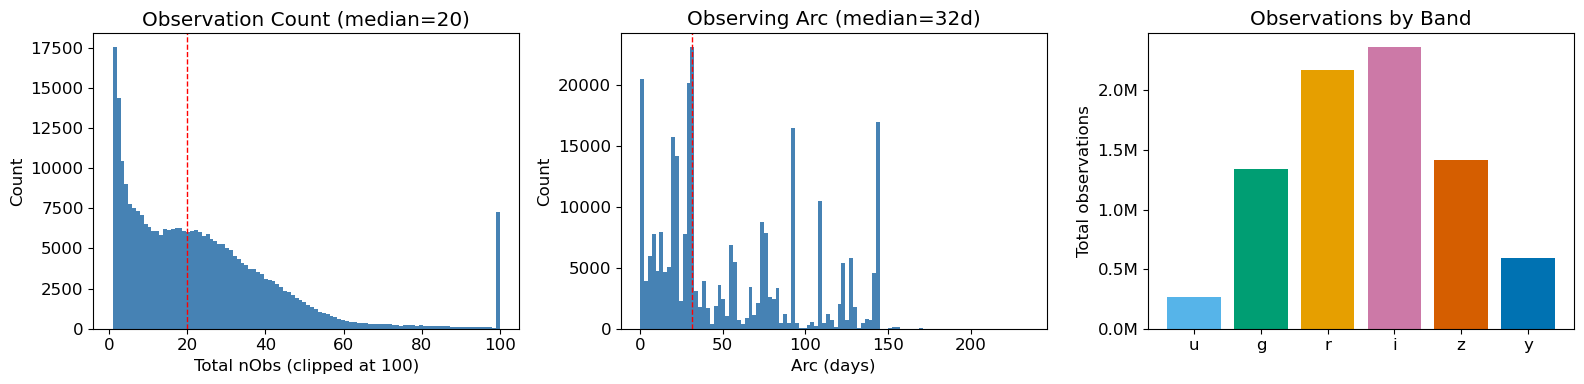

 Band   nObs>0    has H  fit fail   no obs
    u   59,070   34,637       689  240,749
    g  234,434  192,419     4,630   65,385
    r  257,285  222,814     2,412   42,534
    i  259,453  230,351     1,722   40,366
    z  233,980  202,267     1,278   65,839
    y  112,722   90,356       486  187,097

Single-epoch objects (arc=0): 17,528
Objects with no H in any band: 26,692


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# nObs distribution
ax = axes[0]
nobs = df['nObs']
ax.hist(nobs.clip(0, 100), bins=100, color='steelblue', edgecolor='none')
ax.set_xlabel('Total nObs (clipped at 100)')
ax.set_ylabel('Count')
ax.set_title(f'Observation Count (median={nobs.median():.0f})')
ax.axvline(nobs.median(), color='red', linestyle='--', linewidth=1)

# Arc distribution
ax = axes[1]
arc = df['arc']
ax.hist(arc[arc > 0], bins=100, color='steelblue', edgecolor='none')
ax.set_xlabel('Arc (days)')
ax.set_ylabel('Count')
ax.set_title(f'Observing Arc (median={arc.median():.0f}d)')
ax.axvline(arc.median(), color='red', linestyle='--', linewidth=1)

# Per-band nObs
ax = axes[2]
band_nobs = [df[f'{b}_nObs'].sum() for b in BANDS]
ax.bar(BANDS, band_nobs, color=[BAND_COLORS[b] for b in BANDS])
ax.set_ylabel('Total observations')
ax.set_title('Observations by Band')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

# Completeness table
print(f'{"Band":>5} {"nObs>0":>8} {"has H":>8} {"fit fail":>9} {"no obs":>8}')
for b in BANDS:
    has_obs = (df[f'{b}_nObs'] > 0).sum()
    has_h = df[f'{b}_H'].notna().sum()
    failed = df[f'{b}_slope_fit_failed'].sum()
    no_obs = (df[f'{b}_nObs'] == 0).sum()
    print(f'{b:>5} {has_obs:>8,} {has_h:>8,} {failed:>9,} {no_obs:>8,}')
print()
print(f'Single-epoch objects (arc=0): {(df["arc"]==0).sum():,}')
print(f'Objects with no H in any band: {(~(df[[f"{b}_H" for b in BANDS]].notna().any(axis=1))).sum():,}')

## 2. H Magnitude Distributions

The absolute magnitude H distribution should peak around 17-18 for a typical MBA population. Very bright objects (H < 5) are large TNOs/dwarf planets. Very faint objects or extreme outliers may indicate bad fits.

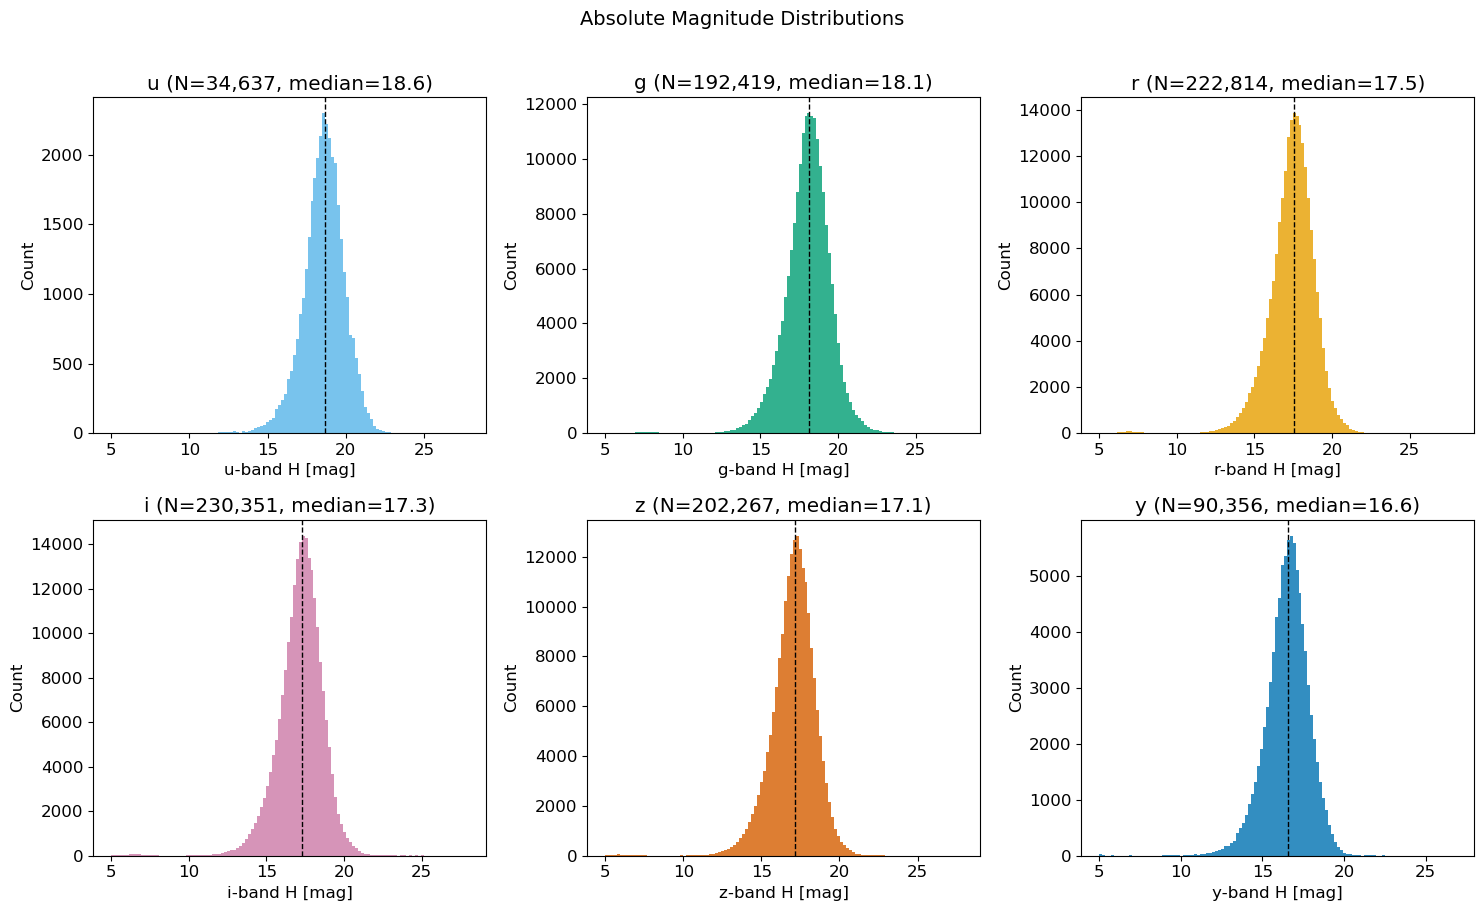

u: 1 objects with H<5, 6 with H>25
g: 5 objects with H<5, 51 with H>25
r: 15 objects with H<5, 48 with H>25
i: 25 objects with H<5, 52 with H>25
z: 34 objects with H<5, 30 with H>25
y: 30 objects with H<5, 9 with H>25


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    h = df[f'{b}_H'].dropna()
    ax.hist(h.clip(5, 28), bins=120, color=BAND_COLORS[b],
            alpha=0.8, edgecolor='none')
    ax.set_xlabel(f'{b}-band H [mag]')
    ax.set_ylabel('Count')
    ax.set_title(f'{b} (N={len(h):,}, median={h.median():.1f})')
    ax.axvline(h.median(), color='black', linestyle='--', linewidth=1)

fig.suptitle('Absolute Magnitude Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Flag extremes
for b in BANDS:
    h = df[f'{b}_H'].dropna()
    n_bright = (h < 5).sum()
    n_faint = (h > 25).sum()
    if n_bright > 0 or n_faint > 0:
        print(f'{b}: {n_bright} objects with H<5, {n_faint} with H>25')

The H distributions look reasonable — unimodal peaks around 17-18 mag, consistent with a main-belt dominated sample. The u-band and y-band have fewer objects due to fewer observations. Very bright objects (H < 5) exist in small numbers and correspond to known large TNOs/dwarf planets (see section 6).

## 3. Cross-Band Colors

Asteroid colors should be small and consistent. The g-r color for asteroids is typically 0.4-0.8 mag. Extreme colors (|color| > 3) likely indicate bad fits in one or both bands.

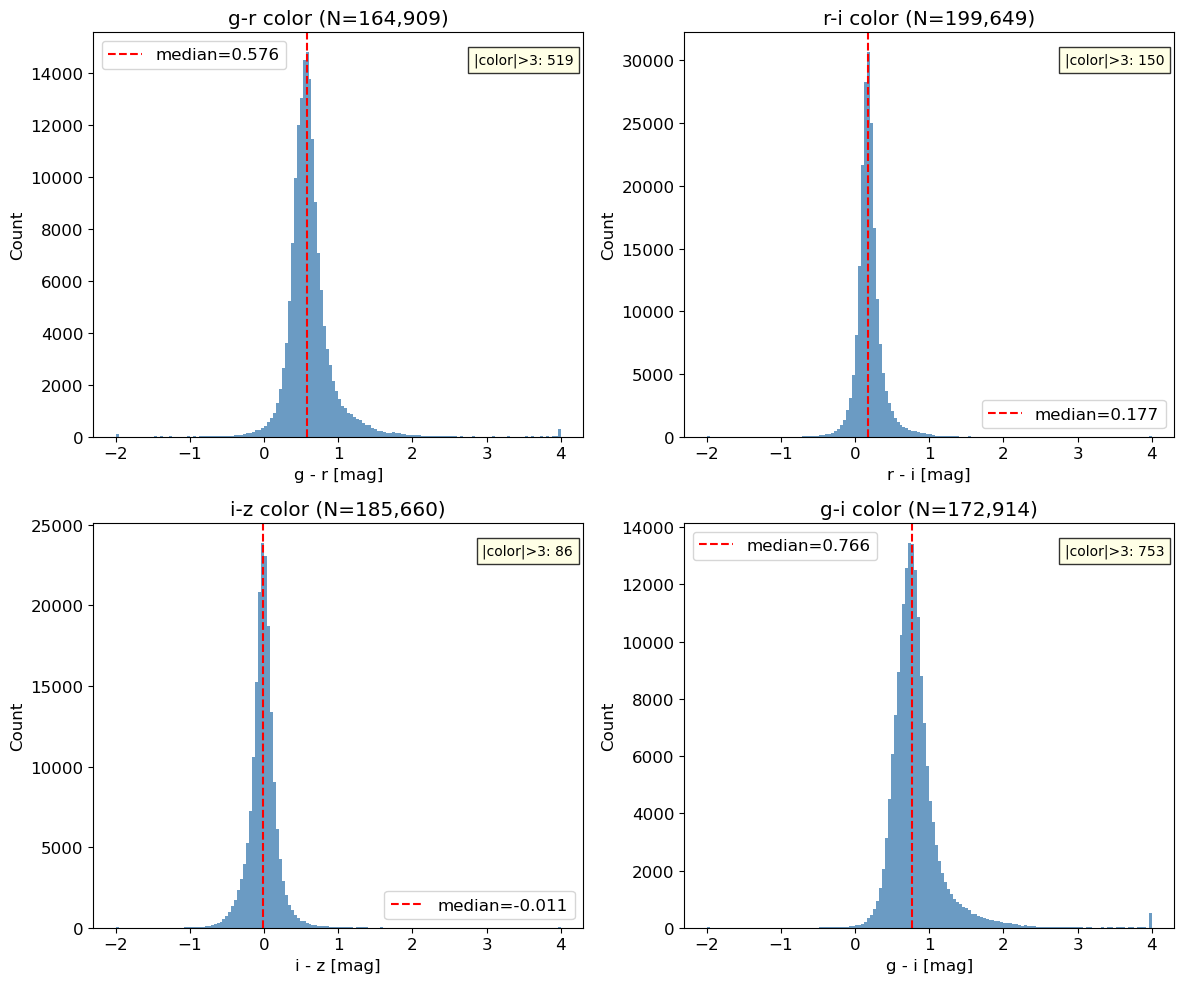

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

pairs = [('g', 'r'), ('r', 'i'), ('i', 'z'), ('g', 'i')]
for ax, (b1, b2) in zip(axes.flat, pairs):
    h1 = df[f'{b1}_H']
    h2 = df[f'{b2}_H']
    mask = h1.notna() & h2.notna()
    color = h1[mask] - h2[mask]
    clipped = color.clip(-2, 4)
    ax.hist(clipped, bins=150, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(color.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'median={color.median():.3f}')
    ax.set_xlabel(f'{b1} - {b2} [mag]')
    ax.set_ylabel('Count')
    ax.set_title(f'{b1}-{b2} color (N={mask.sum():,})')
    ax.legend()
    n_extreme = (color.abs() > 3).sum()
    if n_extreme > 0:
        ax.text(0.98, 0.95, f'|color|>3: {n_extreme:,}',
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

In [5]:
# Investigate extreme colors — are they low-nObs artifacts?
h_g = df['g_H']
h_r = df['r_H']
mask = h_g.notna() & h_r.notna()
color_gr = h_g[mask] - h_r[mask]
extreme = mask & (color_gr.abs() > 3)
print(f'Objects with |g-r| > 3: {extreme.sum():,}')
print(f'  nObs distribution:')
for col in ['g_nObs', 'r_nObs']:
    v = df[col][extreme]
    print(f'    {col}: median={v.median():.0f}, mean={v.mean():.1f}')

print()
print('Almost all extreme colors come from low-nObs objects:')
for lo, hi in [(2, 2), (3, 5), (6, 10), (11, 1000)]:
    sel = extreme & (df['g_nObs'] >= lo) & (df['g_nObs'] <= hi)
    print(f'  g_nObs {lo}-{hi}: {sel.sum()}')

print()
print('Sample of extreme-color objects:')
sample = df[extreme].head(5)
for _, row in sample.iterrows():
    print(f'  {row["designation"]}: g_H={row["g_H"]:.2f}, r_H={row["r_H"]:.2f}, '
          f'g-r={row["g_H"]-row["r_H"]:.2f}, g_nObs={row["g_nObs"]}, r_nObs={row["r_nObs"]}')

Objects with |g-r| > 3: 519
  nObs distribution:
    g_nObs: median=2, mean=2.8
    r_nObs: median=4, mean=5.0

Almost all extreme colors come from low-nObs objects:
  g_nObs 2-2: 394
  g_nObs 3-5: 115
  g_nObs 6-10: 7
  g_nObs 11-1000: 3

Sample of extreme-color objects:
  1978 EA3: g_H=15.28, r_H=12.11, g-r=3.17, g_nObs=2, r_nObs=2
  1981 EK12: g_H=20.07, r_H=15.06, g-r=5.01, g_nObs=2, r_nObs=2
  1981 EK16: g_H=20.21, r_H=15.89, g-r=4.32, g_nObs=2, r_nObs=6
  1981 ER24: g_H=20.89, r_H=17.75, g-r=3.14, g_nObs=2, r_nObs=2
  1981 EG48: g_H=20.14, r_H=15.81, g-r=4.33, g_nObs=2, r_nObs=7


**Colors look reasonable overall.** Median g-r ≈ 0.58, r-i ≈ 0.18, i-z ≈ -0.01, consistent with typical S- and C-type asteroid populations. Extreme colors (|color| > 3) affect < 0.5% of objects and are dominated by low-nObs objects (especially nObs=2) where the H fit is poorly constrained in one band.

## 4. H Errors and Chi-Squared

With `fixedG12=0.5`, H errors should be well-behaved. Reduced chi-squared far from 1 indicates either underestimated measurement errors, intrinsic variability, or model mismatch.

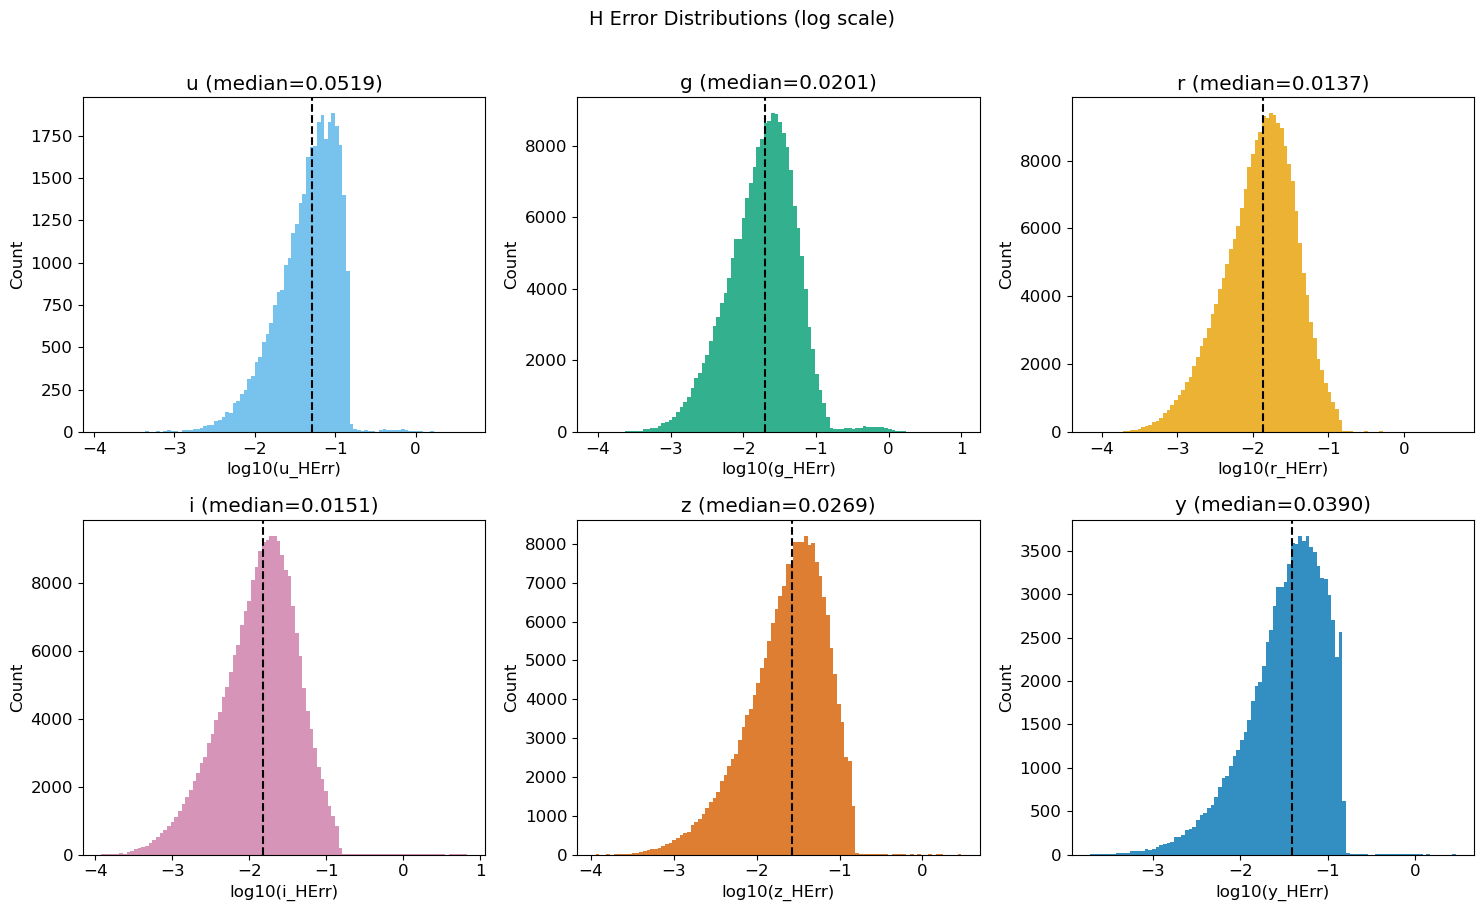

Objects with HErr < 0.001 (may indicate very bright / high-SNR):
  u: 43
  g: 1,396
  r: 4,704
  i: 5,049
  z: 1,788
  y: 407


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    he = df[f'{b}_HErr'].dropna()
    ax.hist(np.log10(he.clip(1e-5, 10)), bins=100,
            color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax.set_xlabel(f'log10({b}_HErr)')
    ax.set_ylabel('Count')
    ax.set_title(f'{b} (median={he.median():.4f})')
    ax.axvline(np.log10(he.median()), color='black', linestyle='--')

fig.suptitle('H Error Distributions (log scale)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Suspiciously small errors
print('Objects with HErr < 0.001 (may indicate very bright / high-SNR):')
for b in BANDS:
    he = df[f'{b}_HErr']
    tiny = he.notna() & (he < 0.001)
    print(f'  {b}: {tiny.sum():,}')

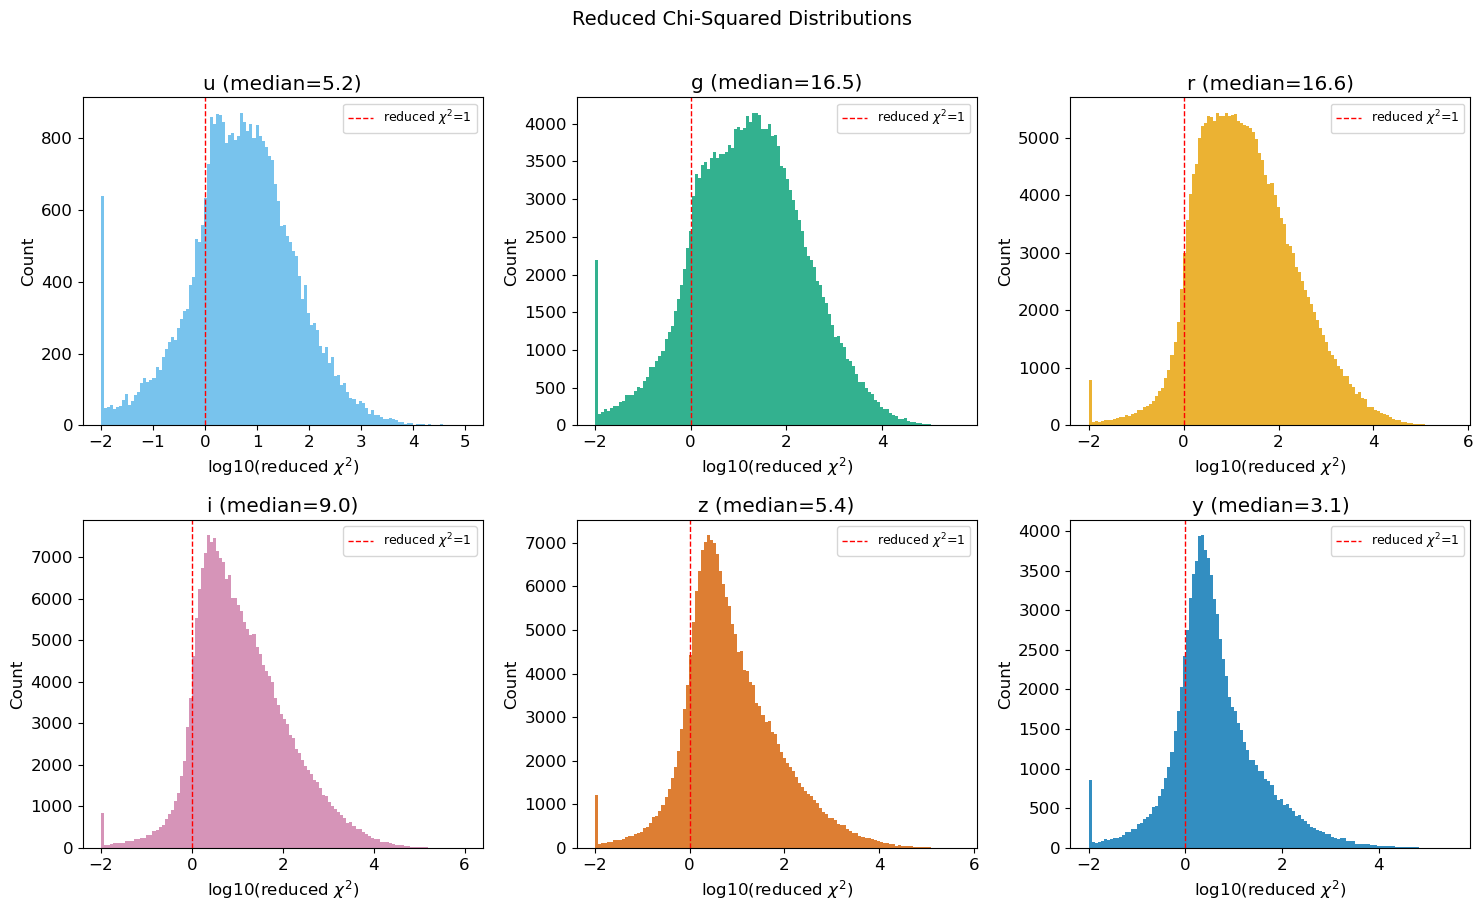

Median reduced chi2 by band:
  u: median=5.2, 40.3% have reduced chi2 < 3
  g: median=16.5, 27.1% have reduced chi2 < 3
  r: median=16.6, 21.9% have reduced chi2 < 3
  i: median=9.0, 29.0% have reduced chi2 < 3
  z: median=5.4, 37.1% have reduced chi2 < 3
  y: median=3.1, 49.1% have reduced chi2 < 3


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    chi2 = df[f'{b}_Chi2']
    nused = df[f'{b}_nObsUsed'].astype(float)
    mask = chi2.notna() & (nused > 1)
    red_chi2 = chi2[mask] / (nused[mask] - 1)
    ax.hist(np.log10(red_chi2.clip(1e-2, 1e6)), bins=120,
            color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax.axvline(0, color='red', linestyle='--', linewidth=1,
               label='reduced $\\chi^2$=1')
    ax.set_xlabel(f'log10(reduced $\\chi^2$)')
    ax.set_ylabel('Count')
    ax.set_title(f'{b} (median={red_chi2.median():.1f})')
    ax.legend(fontsize=9)

fig.suptitle('Reduced Chi-Squared Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Median reduced chi2 by band:')
for b in BANDS:
    chi2 = df[f'{b}_Chi2']
    nused = df[f'{b}_nObsUsed'].astype(float)
    mask = chi2.notna() & (nused > 1)
    rc = chi2[mask] / (nused[mask] - 1)
    pct_good = (rc < 3).mean() * 100
    print(f'  {b}: median={rc.median():.1f}, {pct_good:.1f}% have reduced chi2 < 3')

**H errors are well-behaved**, with medians of 0.01-0.05 mag depending on band. Thousands of objects have HErr < 0.001, corresponding to bright, well-observed asteroids — this is expected.

**Reduced chi-squared is universally elevated** (medians ~3-20 depending on band). This is *not* a consequence of fixing G12 — the free-fit run showed similar values. The likely causes are:
- Photometric error bars are underestimated (the 0.01 mag `magSigmaFloor` helps but doesn't fully account for systematics)
- Intrinsic brightness variations (rotation light curves) that the static HG12 model cannot capture
- Possible issues with the photometric calibration at different epochs

The highest chi2 objects (>10^6) tend to be bright asteroids with many observations, suggesting the model is a poor fit for these well-measured objects, likely due to rotation.

## 5. Orbital Parameters

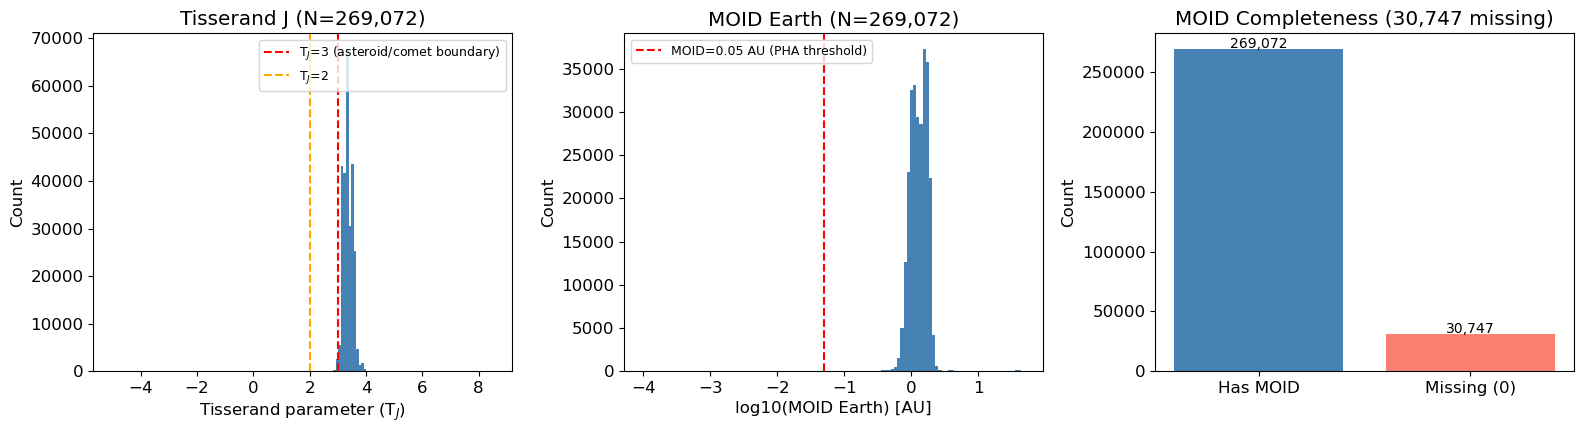

Objects with MOID=0 (not computed): 30,747 (10.3%)
Negative Tisserand J (hyperbolic?): 6
PHAs (MOID < 0.05 AU): 348


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Tisserand J
ax = axes[0]
tj = df['tisserand_J']
tj_nz = tj[tj != 0]
ax.hist(tj_nz.clip(-5, 10), bins=150, color='steelblue', edgecolor='none')
ax.axvline(3.0, color='red', linestyle='--', label='T$_J$=3 (asteroid/comet boundary)')
ax.axvline(2.0, color='orange', linestyle='--', label='T$_J$=2')
ax.set_xlabel('Tisserand parameter (T$_J$)')
ax.set_ylabel('Count')
ax.set_title(f'Tisserand J (N={len(tj_nz):,})')
ax.legend(fontsize=9)

# MOID Earth
ax = axes[1]
moid = df['MOIDEarth']
moid_nz = moid[moid > 0]
ax.hist(np.log10(moid_nz.clip(1e-4, 100)), bins=120,
        color='steelblue', edgecolor='none')
ax.axvline(np.log10(0.05), color='red', linestyle='--',
           label='MOID=0.05 AU (PHA threshold)')
ax.set_xlabel('log10(MOID Earth) [AU]')
ax.set_ylabel('Count')
ax.set_title(f'MOID Earth (N={len(moid_nz):,})')
ax.legend(fontsize=9)

# Zero MOID objects
ax = axes[2]
zero_moid = (moid == 0).sum()
nonzero_moid = (moid > 0).sum()
ax.bar(['Has MOID', 'Missing (0)'], [nonzero_moid, zero_moid],
       color=['steelblue', 'salmon'])
ax.set_ylabel('Count')
ax.set_title(f'MOID Completeness ({zero_moid:,} missing)')
for j, v in enumerate([nonzero_moid, zero_moid]):
    ax.text(j, v + 1000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Objects with MOID=0 (not computed): {zero_moid:,} ({zero_moid/len(df)*100:.1f}%)')
print(f'Negative Tisserand J (hyperbolic?): {(tj_nz < 0).sum()}')
print(f'PHAs (MOID < 0.05 AU): {(moid_nz < 0.05).sum():,}')

In [9]:
# Investigate negative Tisserand J objects
neg_tj = df[(df['tisserand_J'] < 0) & (df['tisserand_J'] != 0)]
print(f'Objects with negative Tisserand J: {len(neg_tj)}')
print()
for _, row in neg_tj.iterrows():
    print(f'  {row["designation"]}: T_J={row["tisserand_J"]:.3f}, '
          f'nObs={row["nObs"]}, arc={row["arc"]:.1f}d')

Objects with negative Tisserand J: 6

  2005 VD: T_J=-1.395, nObs=20, arc=30.7d
  2015 RM306: T_J=-4.122, nObs=22, arc=44.8d
  2021 XZ3: T_J=-1.677, nObs=3, arc=26.9d
  2024 LY9: T_J=-2.984, nObs=37, arc=38.1d
  2024 PP38: T_J=-2.728, nObs=1, arc=0.0d
  C/2025 N1: T_J=-22.437, nObs=12, arc=21.2d


**Tisserand parameter** is dominated by T_J > 3 (main-belt asteroids), with a small tail of JFC-like objects (2 < T_J < 3). This is expected for an LSST survey.

**30,747 objects (10.3%) have zero MOID and Tisserand**, meaning orbital elements were not matched in the MPC orbit catalog. These are objects whose designations weren't found in the `mpcorb` table — this should be investigated upstream.

**6 objects have negative Tisserand J** — these are hyperbolic or near-hyperbolic orbits (interstellar objects or long-period comets). The most extreme is C/2025 N1 with T_J = -22.4, which is likely a comet. These are physically valid, not errors.

## 6. Extendedness

Asteroids should appear point-like (extendedness ≈ 0). High extendedness may indicate contamination, trailing, or confusion with galaxies.

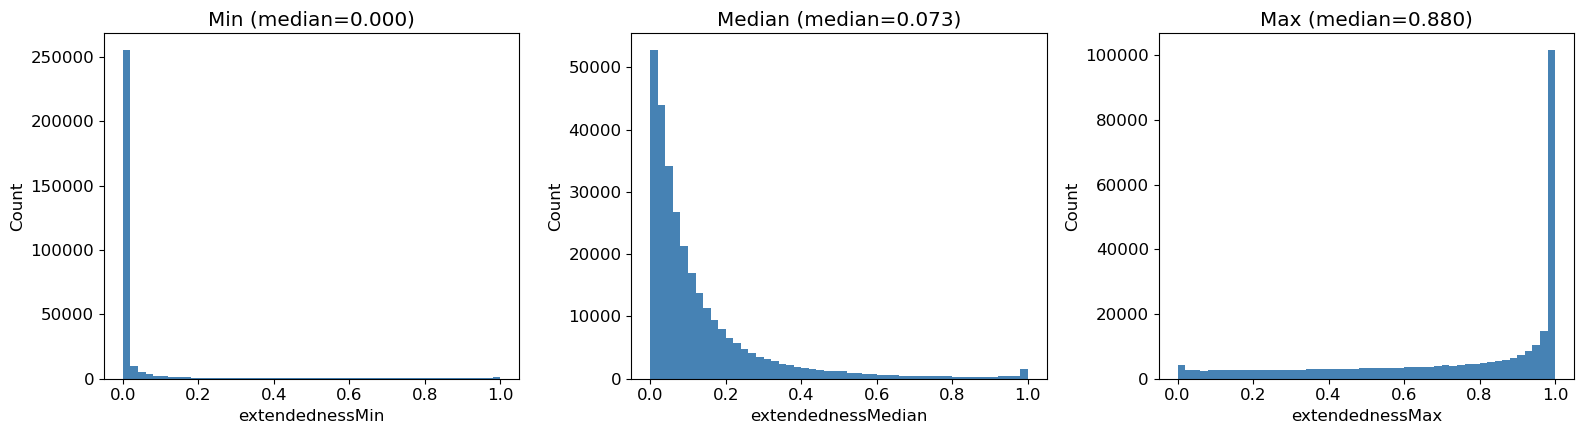

Median extendedness distribution:
  < 0.1 (point-like): 179,195 (60.2%)
  0.1-0.5: 104,045
  >= 0.5 (extended): 14,663
  == 1.0 (fully extended): 261


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, label in zip(axes,
    ['extendednessMin', 'extendednessMedian', 'extendednessMax'],
    ['Min', 'Median', 'Max']):
    v = df[col].dropna()
    ax.hist(v, bins=50, color='steelblue', edgecolor='none')
    ax.set_xlabel(f'extendedness{label}')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} (median={v.median():.3f})')

plt.tight_layout()
plt.show()

ext_med = df['extendednessMedian'].dropna()
print(f'Median extendedness distribution:')
print(f'  < 0.1 (point-like): {(ext_med < 0.1).sum():,} ({(ext_med < 0.1).mean()*100:.1f}%)')
print(f'  0.1-0.5: {((ext_med >= 0.1) & (ext_med < 0.5)).sum():,}')
print(f'  >= 0.5 (extended): {(ext_med >= 0.5).sum():,}')
print(f'  == 1.0 (fully extended): {(ext_med == 1.0).sum():,}')

**Most objects are point-like** (60% have median extendedness < 0.1), as expected for asteroids. However:

- **14,663 objects (4.9%)** have median extendedness ≥ 0.5, and **261 have median extendedness = 1.0**. These may be trailed detections, confused with extended sources, or genuinely resolved (for nearby objects)
- The **extendednessMax** distribution is bimodal, peaking at 0 and 1 — many objects have at least one detection classified as extended. This is likely due to trailing at certain epochs
- High-extendedness objects have significantly lower chi2 values (median r_Chi2 = 7 vs 222 for point-like), which is unexpected and may indicate that extended detections have inflated error bars

## 7. Bright Objects Spot Check

Very bright objects (H < 5) should correspond to known large bodies. Let's verify.

In [11]:
bright = df[df['r_H'].notna() & (df['r_H'] < 5)].sort_values('r_H')
print(f'{len(bright)} objects with r_H < 5:\n')
print(f'{"designation":>20s} {"r_H":>6} {"g_H":>6} {"i_H":>6} '
      f'{"r_nObs":>6} {"nObs":>5} {"arc":>6}')
for _, row in bright.iterrows():
    print(f'{row["designation"]:>20s} {row["r_H"]:>6.2f} '
          f'{row["g_H"]:>6.2f} {row["i_H"]:>6.2f} '
          f'{row["r_nObs"]:>6} {row["nObs"]:>5} '
          f'{row["arc"]:>6.1f}')

15 objects with r_H < 5:

         designation    r_H    g_H    i_H r_nObs  nObs    arc
           2007 OR10   1.79   3.02   1.17     15    49   74.0
           2002 LM60   2.28    nan    nan      2     8   29.9
           2005 RN43   3.47   4.24   3.16      9    43   66.0
           2003 OP32   3.85   4.44   3.61      7    33   20.9
          2016 NY210   4.16   4.97   3.72      8    57   82.8
          2014 OE394   4.58   5.44   4.23     10    59   91.9
           2002 KX14   4.59   5.48   4.18     43   228   84.8
           1996 GQ21   4.70    nan   4.30      3    26   23.0
           2007 JH43   4.77   5.35   4.26      6    23   28.2
           2008 OG19   4.78   5.60   4.37     11    39   67.9
           2011 OA60   4.85   5.50   4.60     12    69  108.8
           2003 QW90   4.87    nan    nan      2     2    0.0
          2003 QX113   4.89   5.71   4.60     14    37  142.9
          2014 OJ394   4.97   5.60   4.65     10    47   84.0
           2014 JP80   4.97   5.78   4.60   

The brightest objects are well-known large TNOs and dwarf planets:
- **2007 OR10** (Gonggong, r_H=1.8) — known large TNO
- **2002 LM60** (Quaoar, r_H=2.3) — known dwarf planet candidate
- **2005 RN43**, **2003 OP32** — known large TNOs

These are physically correct, not fitting artifacts. The 2-obs object (2003 QW90, r_H=4.87) should be treated with caution.

## 8. Fit Failures

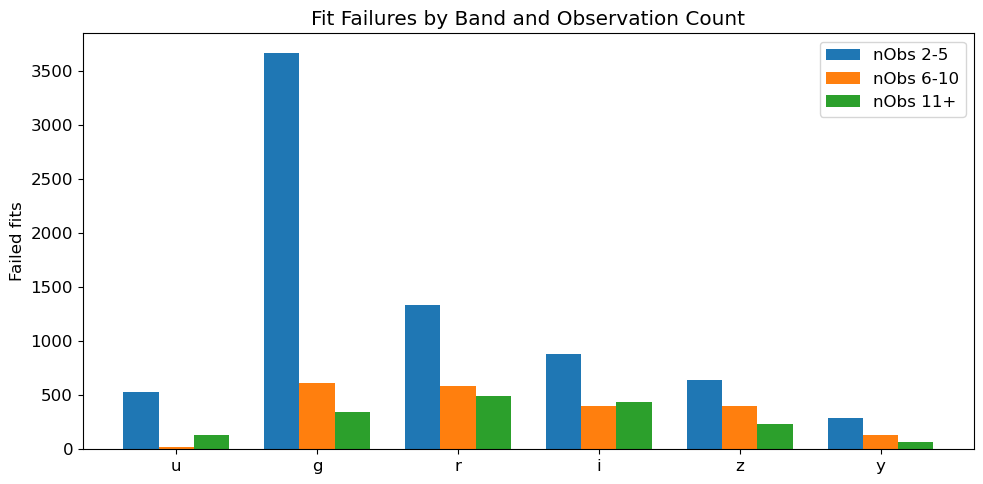

Fits failed with nObs >= 10 in that band:
  u: 133
  g: 388
  r: 560
  i: 496
  z: 280
  y: 77


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(BANDS))
w = 0.25
for j, (lo, hi, label) in enumerate([
    (2, 5, 'nObs 2-5'), (6, 10, 'nObs 6-10'), (11, 1000, 'nObs 11+')
]):
    counts = []
    for b in BANDS:
        mask = (df[f'{b}_slope_fit_failed']
                & (df[f'{b}_nObs'] >= lo)
                & (df[f'{b}_nObs'] <= hi))
        counts.append(mask.sum())
    ax.bar(x + j * w, counts, w, label=label)

ax.set_xticks(x + w)
ax.set_xticklabels(BANDS)
ax.set_ylabel('Failed fits')
ax.set_title('Fit Failures by Band and Observation Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Fits failed with nObs >= 10 in that band:')
for b in BANDS:
    failed_many = (df[f'{b}_slope_fit_failed'] & (df[f'{b}_nObs'] >= 10)).sum()
    print(f'  {b}: {failed_many:,}')

**Most fit failures occur at low nObs**, as expected. However, **hundreds of objects per band fail despite having 10+ observations**. These are worth investigating — possible causes include:
- All observations at nearly the same phase angle (degenerate geometry)
- Extreme outlier measurements corrupting the fit
- Numerical issues in the least-squares solver

## 9. H vs H Error Diagnostic

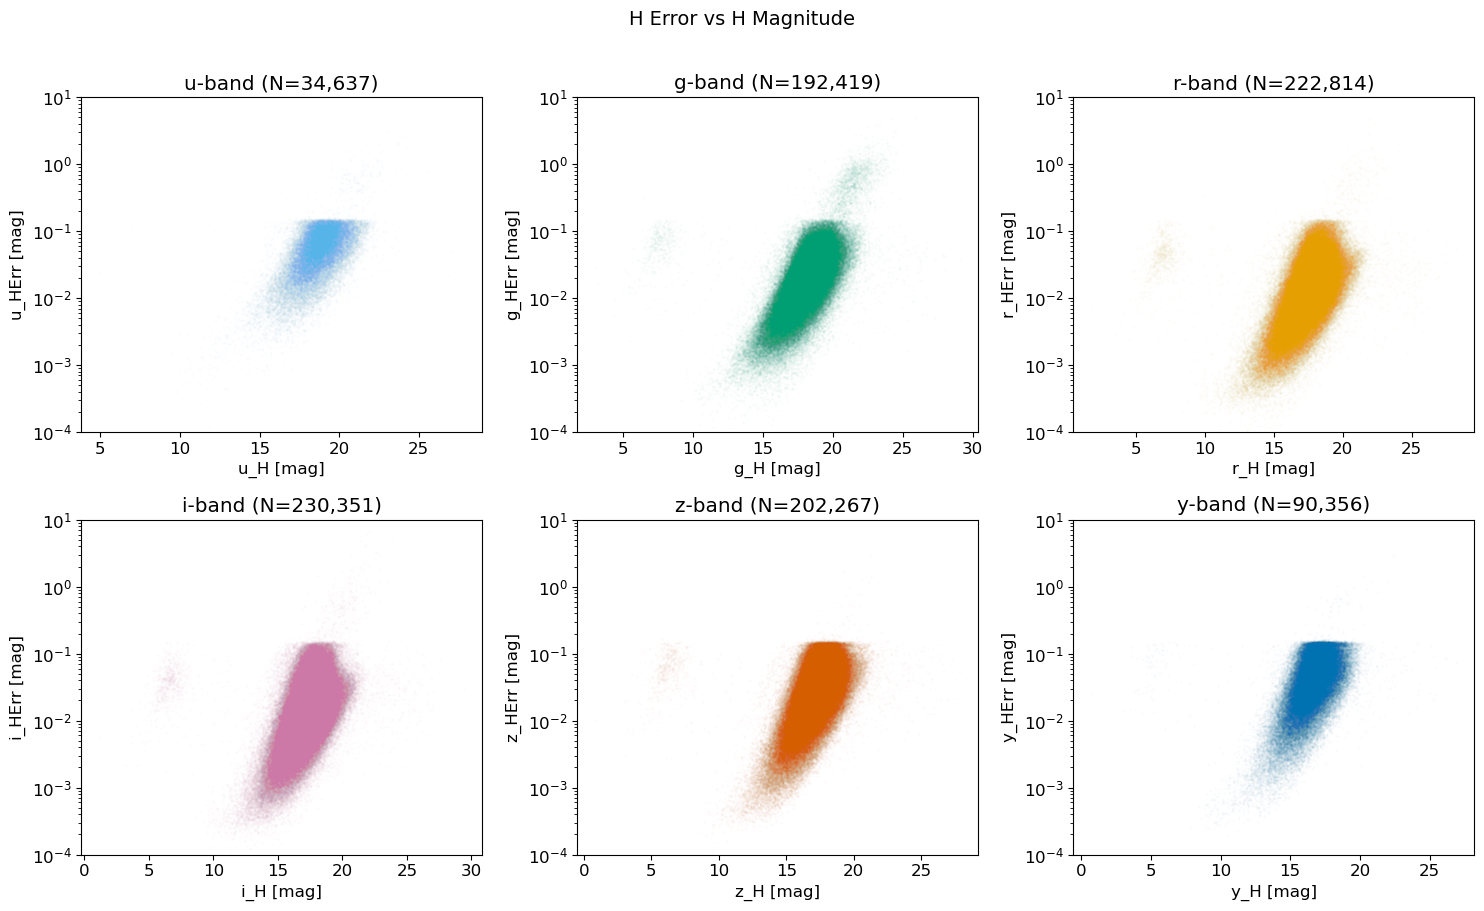

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, b in enumerate(BANDS):
    ax = axes.flat[i]
    h = df[f'{b}_H']
    he = df[f'{b}_HErr']
    mask = h.notna() & he.notna()
    ax.scatter(h[mask], he[mask], s=0.1, alpha=0.05,
               color=BAND_COLORS[b], rasterized=True)
    ax.set_xlabel(f'{b}_H [mag]')
    ax.set_ylabel(f'{b}_HErr [mag]')
    ax.set_ylim(1e-4, 10)
    ax.set_yscale('log')
    ax.set_title(f'{b}-band (N={mask.sum():,})')

fig.suptitle('H Error vs H Magnitude', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

H errors increase toward fainter magnitudes, as expected (fainter objects have lower SNR). The relationship is smooth with no obvious artifacts. The error floor set by `magSigmaFloor=0.01` prevents unrealistically small errors at the bright end.

## Summary of Findings

### Looks Good
1. **H distributions** are unimodal and consistent with an MBA-dominated population
2. **Cross-band colors** are physically reasonable (g-r ≈ 0.58, r-i ≈ 0.18)
3. **Bright objects** correspond to known large TNOs/dwarf planets
4. **Tisserand J** distribution is dominated by T_J > 3 (asteroids), with a small comet/JFC tail
5. **H errors** are well-behaved and scale sensibly with magnitude
6. **No null or duplicate designations**
7. **No impossible values** (no negative H, no nObsUsed > nObs)

### Notable Issues
1. **30,747 objects (10.3%) have zero MOID/Tisserand** — orbital elements not matched in MPC catalog. These need investigation upstream.
2. **Reduced chi-squared is universally elevated** (median 3-20), likely due to underestimated photometric errors and/or rotation light curves. The `magSigmaFloor=0.01` helps but doesn't fully resolve this.
3. **~500 extreme-color objects** (|g-r| > 3) — almost all from 2-obs fits; not a systematic issue but worth flagging in catalogs.
4. **~500-600 fit failures per band despite 10+ observations** — suggests pathological phase angle distributions or outlier measurements.
5. **14,663 objects have median extendedness ≥ 0.5** — may indicate trailing or source confusion; their photometry should be treated with caution.
6. **6 objects have negative Tisserand J** — these are physically valid (hyperbolic/long-period orbits, including at least one comet).